# 07. Validação Visual de Predições e Playground de Inferência

Este notebook fornece um ambiente interativo e visual para testar, validar e comparar as predições dos modelos treinados (**MLP**, **Logistic Regression** e **Gradient Boosting**) em trechos de código HTML.

### Funcionalidades:
1. **Renderização Visual de HTML**: Visualização em tempo real do fragmento HTML inserido.
2. **Classificação e Confiança**: Exibição da ação recomendada com cores e nível de confiança.
3. **Distribuição de Probabilidade**: Gráficos de barras mostrando as probabilidades calculadas para cada classe.
4. **Comparação Inter-Modelos**: Teste simultâneo nos 3 modelos para análise comparativa.
5. **Bateria de Testes Pré-definidos**: Casos de teste variados cobrindo imagens, botões, headings, formulários e tabelas.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import HTML, display

ROOT = Path.cwd().parents[0] if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

from src.config import ACTION_CLASSES, ACTIVE_PROFILES, get_rel_path
from src.inference.predict import predict_action

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 4)
print("Setup de validação de predições completo.")

Setup de validação de predições completo.


## 1. Função de Validação Visual de Predições

A função `visualize_prediction(html_str, model_type, profile)` recebe um trecho HTML, chama o pipeline de inferência e exibe:
- O HTML renderizado na página
- Card visual com o resultado da predição (com cores indicativas)
- Gráfico de barras da distribuição de probabilidades

In [2]:
COLOR_MAP = {
    "ADD_ALT": "#2b5c8f",      # Azul escuro
    "ADD_ARIA": "#d97706",     # Laranja/Âmbar
    "FIX_HEADING": "#9333ea",  # Roxo
    "NO_ACTION": "#16a34a",    # Verde
}

def visualize_prediction(html_str: str, model_type: str = "mlp", profile: str = "VISUAL"):
    """Realiza a inferência em um trecho HTML e exibe o resultado de forma visual."""
    result = predict_action(html_str, profile=profile, model_type=model_type)
    action = result["predicted_action"]
    confidence = result["confidence"]
    probs = result["probabilities"]
    
    color = COLOR_MAP.get(action, "#333333")
    
    # 1. Card HTML de resultado
    card_html = f"""
    <div style="border: 2px solid {color}; border-radius: 8px; padding: 15px; background-color: #fafafa; font-family: sans-serif; margin-bottom: 15px;">
        <h4 style="margin-top:0; color: #555;">Visualização do Componente HTML:</h4>
        <div style="padding: 10px; background: #ffffff; border: 1px dashed #ccc; border-radius: 4px; margin-bottom: 15px;">
            {html_str}
        </div>
        <table style="width: 100%; border-collapse: collapse;">
            <tr>
                <td><strong>Modelo:</strong> <code>{model_type.upper()}</code></td>
                <td><strong>Perfil:</strong> <code>{profile}</code></td>
                <td><strong>Ação Recomendada:</strong> <span style="background-color: {color}; color: white; padding: 4px 10px; border-radius: 12px; font-weight: bold;">{action}</span></td>
                <td><strong>Confiança:</strong> <strong>{confidence*100:.2f}%</strong></td>
            </tr>
        </table>
    </div>
    """
    display(HTML(card_html))
    
    # 2. Gráfico de Barras de Probabilidades
    fig, ax = plt.subplots(figsize=(8, 3))
    classes = list(probs.keys())
    values = [probs[c] for c in classes]
    bar_colors = [COLOR_MAP.get(c, "#888888") for c in classes]
    
    bars = ax.barh(classes, values, color=bar_colors, edgecolor="black", height=0.55)
    ax.set_xlim(0, 1.05)
    ax.set_xlabel("Probabilidade")
    ax.set_title(f"Distribuição de Probabilidades — Modelo: {model_type.upper()}", fontsize=11, fontweight="bold")
    
    for bar in bars:
        w = bar.get_width()
        ax.text(w + 0.02, bar.get_y() + bar.get_height()/2, f"{w*100:.2f}%", va="center", fontsize=10, fontweight="bold")
        
    plt.tight_layout()
    plt.show()
    return result

## 2. Testes Individuais de Predição

Execute as células abaixo para testar diferentes tipos de elementos HTML:

Modelo: MLP,Perfil: VISUAL,Ação Recomendada: ADD_ALT,Confiança: 99.90%


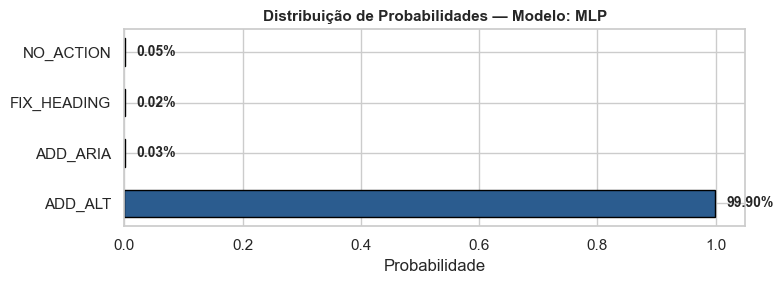

{'html': '<img src="foto_aula.jpg">',
 'profile': 'VISUAL',
 'model_used': 'mlp',
 'predicted_action': 'ADD_ALT',
 'confidence': 0.998995840549469,
 'probabilities': {'ADD_ALT': 0.998995840549469,
  'ADD_ARIA': 0.000316461460897699,
  'FIX_HEADING': 0.00015363175771199167,
  'NO_ACTION': 0.000534134975168854}}

In [3]:
# Exemplo 1: Imagem sem atributo alt (Esperado: ADD_ALT)
visualize_prediction('<img src="foto_aula.jpg">', model_type="mlp")

Modelo: MLP,Perfil: VISUAL,Ação Recomendada: ADD_ARIA,Confiança: 69.32%


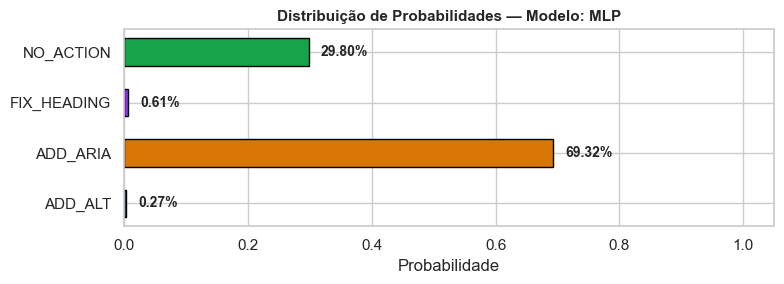

{'html': '<button class="btn-search"><i class="fa fa-search"></i></button>',
 'profile': 'VISUAL',
 'model_used': 'mlp',
 'predicted_action': 'ADD_ARIA',
 'confidence': 0.6931741833686829,
 'probabilities': {'ADD_ALT': 0.0027304780669510365,
  'ADD_ARIA': 0.6931741833686829,
  'FIX_HEADING': 0.006139525678008795,
  'NO_ACTION': 0.29795584082603455}}

In [4]:
# Exemplo 2: Botão interativo sem texto visível ou atributo ARIA (Esperado: ADD_ARIA)
visualize_prediction('<button class="btn-search"><i class="fa fa-search"></i></button>', model_type="mlp")

Modelo: MLP,Perfil: VISUAL,Ação Recomendada: NO_ACTION,Confiança: 99.76%


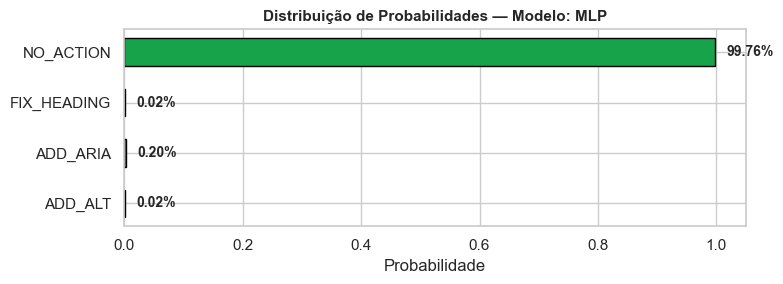

{'html': '<img src="logotipo.png" alt="Logotipo Oficial do Moodle UFABC">',
 'profile': 'VISUAL',
 'model_used': 'mlp',
 'predicted_action': 'NO_ACTION',
 'confidence': 0.9976119995117188,
 'probabilities': {'ADD_ALT': 0.00020645781478378922,
  'ADD_ARIA': 0.0019947863183915615,
  'FIX_HEADING': 0.00018681887013372034,
  'NO_ACTION': 0.9976119995117188}}

In [5]:
# Exemplo 3: Imagem já acessível com alt preenchido (Esperado: NO_ACTION)
visualize_prediction('<img src="logotipo.png" alt="Logotipo Oficial do Moodle UFABC">', model_type="mlp")

## 3. Comparação Inter-Modelos (MLP vs Logistic vs Gradient Boosting)

A função `compare_models_visual(html_str)` executa a classificação simultânea nos 3 modelos e exibe um comparativo lado a lado.

,Modelo,Ação Predita,Confiança,Prob. ADD_ALT,Prob. ADD_ARIA,Prob. FIX_HEADING,Prob. NO_ACTION
0,MLP,ADD_ARIA,69.32%,0.3%,69.3%,0.6%,29.8%
1,LOGISTIC,ADD_ARIA,75.45%,0.7%,75.4%,0.0%,23.8%
2,GB,ADD_ARIA,83.46%,0.0%,83.5%,0.0%,16.5%


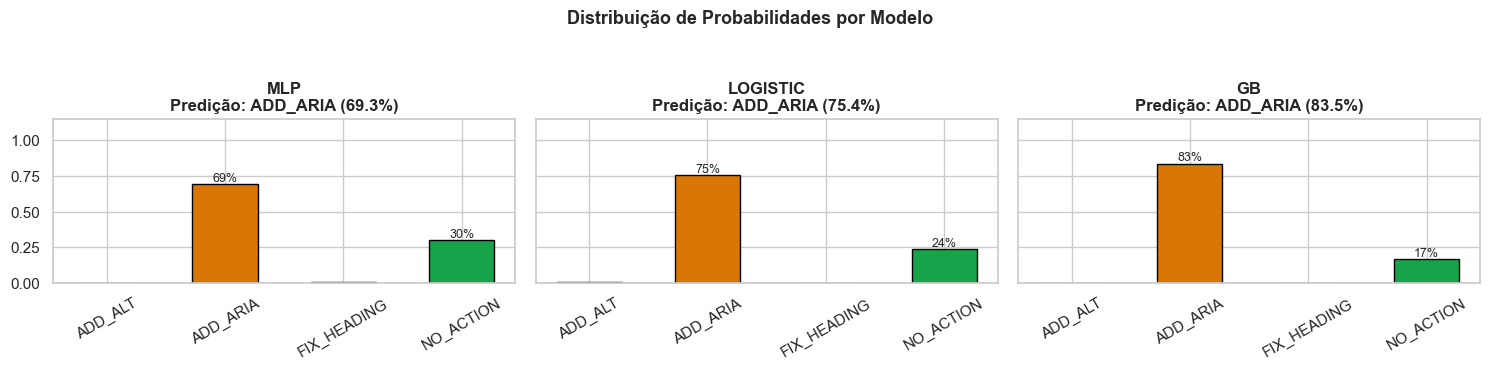

In [6]:
def compare_models_visual(html_str: str):
    """Compara as predições de todos os modelos (MLP, Logistic, Gradient Boosting) para um trecho HTML."""
    models = ["mlp", "logistic", "gb"]
    results = {}
    
    for m in models:
        try:
            results[m] = predict_action(html_str, model_type=m)
        except Exception as e:
            print(f"[WARN] Erro ao testar modelo {m}: {e}")
            
    if not results:
        print("[ERROR] Nenhum modelo disponível para comparação.")
        return
        
    display(HTML(f"<h3>Comparação para o HTML:</h3><div style='padding:8px; background:#f0f4f8; border-radius:4px; margin-bottom:10px;'><code>{html_str}</code></div>"))
    
    # Monta tabela resumo
    summary_data = []
    for m_name, res in results.items():
        summary_data.append({
            "Modelo": m_name.upper(),
            "Ação Predita": res["predicted_action"],
            "Confiança": f"{res['confidence']*100:.2f}%",
            "Prob. ADD_ALT": f"{res['probabilities'].get('ADD_ALT', 0)*100:.1f}%",
            "Prob. ADD_ARIA": f"{res['probabilities'].get('ADD_ARIA', 0)*100:.1f}%",
            "Prob. FIX_HEADING": f"{res['probabilities'].get('FIX_HEADING', 0)*100:.1f}%",
            "Prob. NO_ACTION": f"{res['probabilities'].get('NO_ACTION', 0)*100:.1f}%",
        })
    display(pd.DataFrame(summary_data))
    
    # Plot lado a lado
    fig, axes = plt.subplots(1, len(results), figsize=(5 * len(results), 3.5), sharey=True)
    if len(results) == 1:
        axes = [axes]
        
    for ax, (m_name, res) in zip(axes, results.items()):
        probs = res["probabilities"]
        classes = list(probs.keys())
        values = [probs[c] for c in classes]
        bar_colors = [COLOR_MAP.get(c, "#888888") for c in classes]
        
        bars = ax.bar(classes, values, color=bar_colors, edgecolor="black", width=0.55)
        ax.set_ylim(0, 1.15)
        ax.set_title(f"{m_name.upper()}\nPredição: {res['predicted_action']} ({res['confidence']*100:.1f}%)", fontweight="bold")
        ax.tick_params(axis="x", rotation=30)
        
        for bar in bars:
            h = bar.get_height()
            if h > 0.03:
                ax.text(bar.get_x() + bar.get_width()/2, h + 0.02, f"{h*100:.0f}%", ha="center", fontsize=9)
                
    plt.suptitle("Distribuição de Probabilidades por Modelo", fontsize=13, fontweight="bold", y=1.05)
    plt.tight_layout()
    plt.show()

# Executa a comparação em um botão com ícone
compare_models_visual('<button class="icon-only"><i class="fa fa-cog"></i></button>')

## 4. Bateria de Testes com Casos de Uso Reais do Moodle

In [7]:
test_suite = [
    ("Imagem sem ALT", '<img src="foto_aula.jpg">'),
    ("Imagem com ALT vazio", '<img src="linha_divisoria.png" alt="">'),
    ("Imagem com ALT descritivo", '<img src="grafico_desempenho.png" alt="Gráfico de notas da turma">'),
    ("Botão apenas com ícone", '<button class="btn-nav"><span class="icon-next"></span></button>'),
    ("Botão com texto visível", '<button type="submit">Enviar Resposta</button>'),
    ("Heading H3 isolado", '<h3>3.1 Tópico Específico</h3>'),
    ("Input sem label ou ARIA", '<input type="text" name="moodle_search">'),
    ("Link apenas com ícone", '<a href="download.php"><i class="fa fa-download"></i></a>'),
    ("Link acessível", '<a href="plano.pdf">Baixar Plano de Ensino (PDF)</a>'),
]

suite_results = []
for title, html_code in test_suite:
    res = predict_action(html_code, model_type="mlp")
    suite_results.append({
        "Cenário Testado": title,
        "Trecho HTML": html_code,
        "Ação Predita (MLP)": res["predicted_action"],
        "Confiança": f"{res['confidence']*100:.2f}%"
    })

pd.DataFrame(suite_results)

,Cenário Testado,Trecho HTML,Ação Predita (MLP),Confiança
0,Imagem sem ALT,"<img src=""foto_aula.jpg"">",ADD_ALT,99.90%
1,Imagem com ALT vazio,"<img src=""linha_divisoria.png"" alt="""">",NO_ACTION,99.76%
2,Imagem com ALT descritivo,"<img src=""grafico_desempenho.png"" alt=""Gráfico...",NO_ACTION,99.76%
3,Botão apenas com ícone,"<button class=""btn-nav""><span class=""icon-next...",ADD_ARIA,69.32%
4,Botão com texto visível,"<button type=""submit"">Enviar Resposta</button>",NO_ACTION,52.40%
5,Heading H3 isolado,<h3>3.1 Tópico Específico</h3>,FIX_HEADING,89.11%
6,Input sem label ou ARIA,"<input type=""text"" name=""moodle_search"">",NO_ACTION,68.26%
7,Link apenas com ícone,"<a href=""download.php""><i class=""fa fa-downloa...",ADD_ARIA,68.16%
8,Link acessível,"<a href=""plano.pdf"">Baixar Plano de Ensino (PD...",NO_ACTION,90.37%


## 5. Playground Interativo com Controles (ipywidgets)

Altere o HTML, selecione o modelo e veja a inferência ser atualizada automaticamente:

In [9]:
try:
    import ipywidgets as widgets
    from ipywidgets import interact
    
    @interact(
        html_input=widgets.Textarea(
            value='<img src="exemplo.png">',
            placeholder='Insira seu código HTML aqui...',
            description='HTML:',
            layout=widgets.Layout(width='80%', height='80px')
        ),
        modelo=widgets.Dropdown(
            options=['mlp', 'logistic', 'gb'],
            value='mlp',
            description='Modelo:'
        ),
        perfil=widgets.Dropdown(
            options=ACTIVE_PROFILES,
            value='VISUAL',
            description='Perfil:'
        )
    )
    def interactive_predict(html_input, modelo, perfil):
        if html_input.strip():
            visualize_prediction(html_input, model_type=modelo, profile=perfil)
except ImportError:
    print("ipywidgets não instalado no ambiente. Utilize a função visualize_prediction(html_str) diretamente nas células acima.")

interactive(children=(Textarea(value='<img src="exemplo.png">', description='HTML:', layout=Layout(height='80p…